In [1]:
import pandas as pd
import shap

from xgboost import XGBClassifier

In [2]:
X_train = pd.read_csv(
    "../data/X_train_resampled.csv"
)

y_train = pd.read_csv(
    "../data/y_train_resampled.csv"
).squeeze()

X_test = pd.read_csv(
    "../data/X_test.csv"
)

y_test = pd.read_csv(
    "../data/y_test.csv"
).squeeze()

In [3]:
model = XGBClassifier(
    random_state=42
)

model.fit(
    X_train,
    y_train
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [4]:
explainer = shap.TreeExplainer(
    model
)

In [5]:
shap_values = explainer.shap_values(
    X_test
)

In [6]:
print(shap_values.shape)

(201, 3)


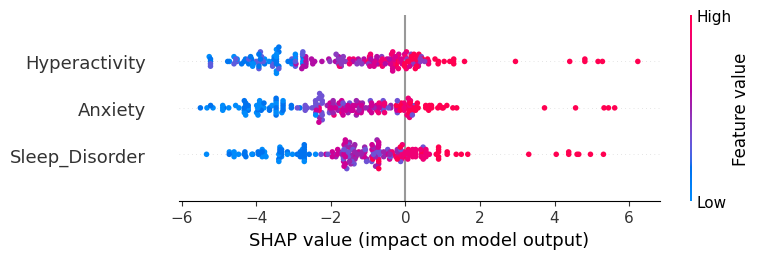

In [7]:
shap.summary_plot(
    shap_values,
    X_test
)

In [8]:
import numpy as np

shap_magnitude = np.mean(
    np.abs(shap_values),
    axis=1
)

print(shap_magnitude[:10])

[1.3513322  3.2166417  2.2485642  1.0446742  0.71478516 0.5737839
 0.7430804  0.60076815 0.5115461  1.0296825 ]


In [9]:
top_patients = np.argsort(
    shap_magnitude
)[::-1]

print(top_patients[:10])

[162 150 100 118 144  48 110 163  52 113]


In [10]:
X_test.iloc[196]

Hyperactivity     8.0
Anxiety           5.0
Sleep_Disorder    5.0
Name: 196, dtype: float64

In [11]:
X_test.iloc[150]

Hyperactivity     1.0
Anxiety           1.0
Sleep_Disorder    5.0
Name: 150, dtype: float64

In [12]:
X_test.iloc[114]

Hyperactivity     8.0
Anxiety           1.0
Sleep_Disorder    4.0
Name: 114, dtype: float64

In [13]:
# SHAP Variance

shap_variance = np.var(
    shap_values,
    axis=1
)

print(shap_variance[:10])

[0.30549458 0.12547605 2.2400138  1.9302778  0.1433556  0.48222232
 0.43280375 0.12165955 0.4630208  1.2286644 ]


In [14]:
variance_df = pd.DataFrame({
    "Patient_ID": np.arange(len(shap_variance)),
    "SHAP_Variance": shap_variance
})

variance_df.head()

,Patient_ID,SHAP_Variance
0,0,0.305495
1,1,0.125476
2,2,2.240014
3,3,1.930278
4,4,0.143356


In [15]:
top_variance_patients = np.argsort(
    shap_variance
)[::-1]

print(top_variance_patients[:10])

[ 33 166 167  70 132  36 199 155  87 183]


In [16]:
variance_df.to_csv(
    "../results/shap_variance.csv",
    index=False
)

In [17]:
from scipy.stats import entropy

abs_shap = np.abs(shap_values)

p = abs_shap / (
    abs_shap.sum(axis=1, keepdims=True) + 1e-10
)

shap_entropy = entropy(
    p.T
)

In [18]:
entropy_df = pd.DataFrame({
    "Patient_ID": np.arange(len(shap_entropy)),
    "SHAP_Entropy": shap_entropy
})

entropy_df.head()

,Patient_ID,SHAP_Entropy
0,0,1.013290
1,1,1.092371
2,2,0.830194
3,3,0.442257
4,4,0.945718


In [19]:
top_entropy_patients = np.argsort(
    shap_entropy
)[::-1]

print(top_entropy_patients[:10])

[138 118  20  72 161  89 198  23  65 113]


In [20]:
entropy_df.to_csv(
    "../results/shap_entropy.csv",
    index=False
)

In [21]:
entropy_df.head()

,Patient_ID,SHAP_Entropy
0,0,1.013290
1,1,1.092371
2,2,0.830194
3,3,0.442257
4,4,0.945718


In [22]:
top_entropy_patients[:10]

array([138, 118,  20,  72, 161,  89, 198,  23,  65, 113])

In [23]:
probs = model.predict_proba(X_test)[:, 1]

In [24]:
print(probs[:10])

[6.49392465e-03 2.42687220e-05 4.42746765e-04 3.38997506e-02
 4.22601439e-02 1.63708806e-01 1.08699284e-01 5.84872626e-02
 9.46708396e-02 2.89389342e-01]


In [25]:
uncertainty = 1 - (
    np.abs(probs - 0.5) * 2
)

In [26]:
uncertainty_df = pd.DataFrame({
    "Patient_ID": np.arange(len(uncertainty)),
    "Prediction_Uncertainty": uncertainty
})

uncertainty_df.head()

,Patient_ID,Prediction_Uncertainty
0,0,0.012988
1,1,0.000049
2,2,0.000885
3,3,0.067800
4,4,0.084520


In [27]:
top_uncertain_patients = np.argsort(
    uncertainty
)[::-1]

print(top_uncertain_patients[:10])

[156 174 151 128 120 115  43 194   9 181]


In [28]:
uncertainty_df.to_csv(
    "../results/prediction_uncertainty.csv",
    index=False
)

In [29]:
probs = model.predict_proba(X_test)[:, 1]

print(probs[:10])

[6.49392465e-03 2.42687220e-05 4.42746765e-04 3.38997506e-02
 4.22601439e-02 1.63708806e-01 1.08699284e-01 5.84872626e-02
 9.46708396e-02 2.89389342e-01]


In [30]:
uncertainty = 1 - (
    np.abs(probs - 0.5) * 2
)

print(uncertainty[:10])

[1.2987852e-02 4.8518181e-05 8.8548660e-04 6.7799509e-02 8.4520280e-02
 3.2741761e-01 2.1739858e-01 1.1697453e-01 1.8934166e-01 5.7877868e-01]


In [31]:
uncertainty_df = pd.DataFrame({
    "Patient_ID": np.arange(len(uncertainty)),
    "Prediction_Uncertainty": uncertainty
})

uncertainty_df.head()

,Patient_ID,Prediction_Uncertainty
0,0,0.012988
1,1,0.000049
2,2,0.000885
3,3,0.067800
4,4,0.084520


In [32]:
top_uncertain_patients = np.argsort(
    uncertainty
)[::-1]

print(top_uncertain_patients[:10])

[156 174 151 128 120 115  43 194   9 181]


In [33]:
from sklearn.neighbors import NearestNeighbors

In [34]:
X_boundary = X_train
y_boundary = y_train

In [35]:
y_boundary = y_train.squeeze()

In [36]:
k = 5

nbrs = NearestNeighbors(
    n_neighbors=k+1
)

nbrs.fit(X_boundary)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",6
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1.0
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [37]:
distances, indices = nbrs.kneighbors(
    X_test
)

In [38]:
boundary_density = []

for i in range(len(X_test)):

    neighbor_ids = indices[i][1:]

    neighbor_labels = y_boundary.iloc[
        neighbor_ids
    ]

    minority_count = np.sum(
        neighbor_labels == 1
    )

    majority_count = np.sum(
        neighbor_labels == 0
    )

    density = (
        minority_count *
        majority_count
    ) / (k*k)

    boundary_density.append(
        density
    )

boundary_density = np.array(
    boundary_density
)

In [39]:
density_df = pd.DataFrame({
    "Patient_ID": np.arange(
        len(boundary_density)
    ),
    "Boundary_Density":
        boundary_density
})

density_df.head()

,Patient_ID,Boundary_Density
0,0,0.0
1,1,0.0
2,2,0.0
3,3,0.0
4,4,0.0


In [40]:
top_boundary_patients = np.argsort(
    boundary_density
)[::-1]

print(
    top_boundary_patients[:10]
)

[197 194 155 161 166 168 170 181 188 133]


In [41]:
density_df.to_csv(
    "../results/boundary_density.csv",
    index=False
)

In [42]:
density_df.head()

,Patient_ID,Boundary_Density
0,0,0.0
1,1,0.0
2,2,0.0
3,3,0.0
4,4,0.0


In [43]:
top_boundary_patients[:10]

array([197, 194, 155, 161, 166, 168, 170, 181, 188, 133])

In [44]:
np.unique(boundary_density)

array([0.  , 0.16, 0.24])

In [45]:
boundary_density.max()

np.float64(0.24)

In [46]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

In [47]:
mag_norm = scaler.fit_transform(
    shap_magnitude.reshape(-1,1)
).flatten()

In [48]:
var_norm = scaler.fit_transform(
    shap_variance.reshape(-1,1)
).flatten()

In [49]:
ent_norm = scaler.fit_transform(
    shap_entropy.reshape(-1,1)
).flatten()

In [50]:
unc_norm = scaler.fit_transform(
    uncertainty.reshape(-1,1)
).flatten()

In [51]:
den_norm = scaler.fit_transform(
    boundary_density.reshape(-1,1)
).flatten()

In [52]:
region_priority_score = (
      0.20 * mag_norm
    + 0.20 * var_norm
    + 0.20 * ent_norm
    + 0.20 * unc_norm
    + 0.20 * den_norm
)

In [53]:
rps_df = pd.DataFrame({
    "Patient_ID": np.arange(
        len(region_priority_score)
    ),
    "Region_Priority_Score":
        region_priority_score
})

rps_df.head()

,Patient_ID,Region_Priority_Score
0,0,0.265826
1,1,0.391223
2,2,0.315380
3,3,0.161310
4,4,0.223500


In [54]:
top_priority_patients = np.argsort(
    region_priority_score
)[::-1]

print(
    top_priority_patients[:20]
)

[166 156 181 155  87 115  43 194   9  24  56 161  69   6 170 168 136 120
  36 188]


In [55]:
rps_df.to_csv(
    "../results/region_priority_score.csv",
    index=False
)

In [56]:
rps_df.head()


,Patient_ID,Region_Priority_Score
0,0,0.265826
1,1,0.391223
2,2,0.315380
3,3,0.161310
4,4,0.223500


In [57]:
top_priority_patients[:20]

array([166, 156, 181, 155,  87, 115,  43, 194,   9,  24,  56, 161,  69,
         6, 170, 168, 136, 120,  36, 188])